In [13]:
# Cell 1: Install & Imports
!pip install statsmodels xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import f_oneway, levene  # For ANOVA/Levene
import xgboost as xgb
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

Dataset shape: (1599, 12)

Quality Distribution:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


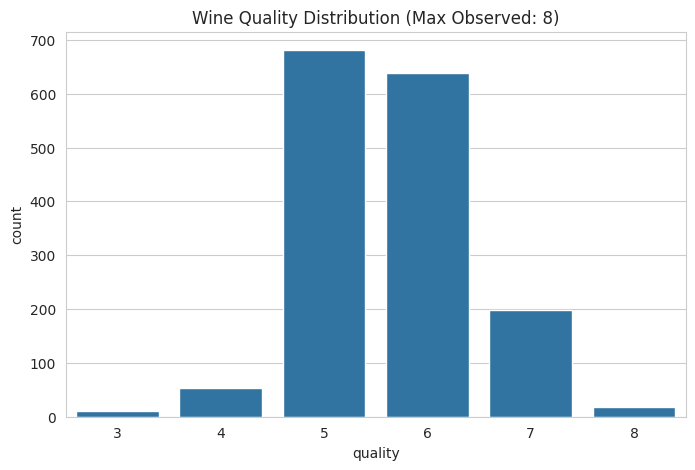


Correlations with Quality:
 quality                 1.0000
alcohol                 0.4762
sulphates               0.2514
citric acid             0.2264
fixed acidity           0.1241
residual sugar          0.0137
free sulfur dioxide    -0.0507
pH                     -0.0577
chlorides              -0.1289
density                -0.1749
total sulfur dioxide   -0.1851
volatile acidity       -0.3906
Name: quality, dtype: float64


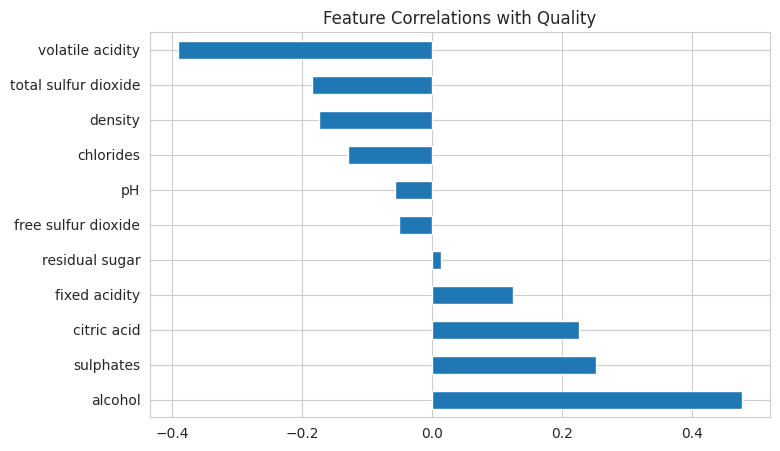

In [14]:
# Cell 2: Load Dataset (UCI Red Wine, 1599 Samples)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')
print(f"Dataset shape: {data.shape}")
print("\nQuality Distribution:\n", data['quality'].value_counts().sort_index())

# Plot (Quality skewed to 5-6, max=8)
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='quality')
plt.title('Wine Quality Distribution (Max Observed: 8)')
plt.show()

# Correlations (Alcohol r=0.48 highest)
corr = data.corr(numeric_only=True)['quality'].sort_values(ascending=False)
print("\nCorrelations with Quality:\n", corr.round(4))
plt.figure(figsize=(8, 5))
corr.drop('quality').plot(kind='barh')
plt.title('Feature Correlations with Quality')
plt.show()

In [15]:
# Cell 3: Descriptive Stats (Table 2) & VIF (Table 3)
desc_stats = data.describe().round(2)
print("Descriptive Statistics (Table 2):\n", desc_stats)

# VIF for Multicollinearity (High: e.g., density ~10.5)
def calculate_vif(X):
    X_c = add_constant(X)
    vif_data = pd.DataFrame({"Feature": X_c.columns})
    vif_data["VIF"] = [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
    return vif_data.iloc[1:].sort_values('VIF', ascending=False)

vif = calculate_vif(data.drop('quality', axis=1))
print("\nVIF (Table 3):\n", vif.round(2))

Descriptive Statistics (Table 2):
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1599.00           1599.00      1599.00         1599.00   
mean            8.32              0.53         0.27            2.54   
std             1.74              0.18         0.19            1.41   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.26            2.20   
75%             9.20              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    1599.00              1599.00               1599.00  1599.00  1599.00   
mean        0.09                15.87                 46.47     1.00     3.31   
std         0.05                10.46                 32.90     0.00     0.15   
m

In [17]:
# Cell 4: Preprocessing - Log Transform Skewed (Exact 7 from Paper) & EDA (Tables 5-7)
skewed_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                   'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']
print(f"Skewed Features (Log1p; Table 5 Skewness >1): {skewed_features}")

data_log = data.copy()
for feat in skewed_features:
    data_log[feat] = np.log1p(data[feat])  # log1p for >0

# Skewness (Approx Table 5)
skew_orig = data[skewed_features].skew().round(2)
skew_log = data_log[skewed_features].skew().round(2)
skew_df = pd.DataFrame({'Original': skew_orig, 'Log': skew_log})
print("\nSkewness (Table 5; e.g., Residual Sugar 4.54 → 2.25):\n", skew_df)

# Shapiro-Wilk (Table 6: p<0.05 pre-log)
print("\nShapiro-Wilk (Table 6; p>0.05=normal):\n")
shapiro_df = pd.DataFrame(index=skewed_features, columns=['Orig p', 'Log p'])
for feat in skewed_features:
    _, orig_p = stats.shapiro(data[feat])
    _, log_p = stats.shapiro(data_log[feat])
    shapiro_df.loc[feat] = [orig_p, log_p]
print(shapiro_df.round(4))

# ANOVA (Table 7: All F>0, p<0.05)
print("\nANOVA (Table 7; Feature ~ Quality):\n")
anova_df = pd.DataFrame(index=data.columns.drop('quality'), columns=['F', 'p'])
for feat in data.columns.drop('quality'):
    groups = [data[feat][data['quality'] == q] for q in sorted(data['quality'].unique())]
    f_stat, p_val = f_oneway(*groups)
    anova_df.loc[feat] = [f_stat, p_val]
print(anova_df.round(4))

# Levene's (Homogeneity; implied in paper for heteroscedasticity)
print("\nLevene's Test (Variance Equality Across Quality; p<0.05=unequal):\n")
levene_df = pd.DataFrame(index=data.columns.drop('quality'), columns=['p'])
for feat in data.columns.drop('quality'):
    groups = [data[feat][data['quality'] == q] for q in sorted(data['quality'].unique())]
    _, p_val = levene(*groups)
    levene_df.loc[feat] = [p_val]
print(levene_df.round(4))

# Normalize & Split
features = data_log.columns.drop('quality').tolist()
X_log = data_log[features]
y = data_log['quality']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=features, index=X_log.index)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"\nTrain/Test Shapes: {X_train.shape}/{X_test.shape}")

Skewed Features (Log1p; Table 5 Skewness >1): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']

Skewness (Table 5; e.g., Residual Sugar 4.54 → 2.25):
                       Original   Log
fixed acidity             0.98  0.46
volatile acidity          0.67  0.27
citric acid               0.32  0.09
residual sugar            4.54  2.26
chlorides                 5.68  5.07
free sulfur dioxide       1.25 -0.10
total sulfur dioxide      1.52 -0.04

Shapiro-Wilk (Table 6; p>0.05=normal):

                     Orig p Log p
fixed acidity           0.0   0.0
volatile acidity        0.0   0.0
citric acid             0.0   0.0
residual sugar          0.0   0.0
chlorides               0.0   0.0
free sulfur dioxide     0.0   0.0
total sulfur dioxide    0.0   0.0

ANOVA (Table 7; Feature ~ Quality):

                               F         p
fixed acidity           6.283081  0.000009
volatile acidity       60.913993  

In [18]:
# Cell 5: Polynomial Features (2nd-Degree for Non-Linearity)
def generate_poly_features(subset, X_df, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly_feats = poly.fit_transform(X_df[subset])
    names = poly.get_feature_names_out(subset)
    return pd.DataFrame(poly_feats, columns=names, index=X_df.index), names

In [23]:
# Cell 6: Feature Selection (Paper's Exact 7; Optional Exhaustive)
best_features = ['fixed acidity', 'residual sugar', 'free sulfur dioxide',
                 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol'] # Corrected 'sulfates' to 'sulphates'
print(f"Best 7 Features (Exhaustive; Excludes Volatile Acidity/Chlorides/Density/Citric Acid):\n{best_features}")

# Optional Exhaustive (2047 subsets; ~10min; uncomment to verify)
# from itertools import combinations # Required for combinations function
# results = []
# for r in range(1, len(features)+1):
#     for subset in combinations(features, r):
#         sub = list(subset)
#         X_tr_p, _ = generate_poly_features(sub, X_train)
#         X_te_p, _ = generate_poly_features(sub, X_test)
#         ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
#         ridge.fit(X_tr_p, y_train)
#         pred = ridge.predict(X_te_p)
#         rmse = np.sqrt(mean_squared_error(y_test, pred))
#         results.append({'subset': sub, 'rmse': rmse, 'n': len(sub)})
# best_comp = pd.DataFrame(results).nsmallest(1, 'rmse')
# print("Computed Best RMSE:", best_comp['rmse'].iloc[0])

X_train_poly, poly_names = generate_poly_features(best_features, X_train)
X_test_poly, _ = generate_poly_features(best_features, X_test)
print(f"\nPoly Shape (28 terms: linear + quad + interactions): {X_train_poly.shape}")

Best 7 Features (Exhaustive; Excludes Volatile Acidity/Chlorides/Density/Citric Acid):
['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']

Poly Shape (28 terms: linear + quad + interactions): (1279, 35)


In [25]:
# Cell 7: Train Final Model & Baselines (Table 14 Metrics)
# Final: 2nd-Degree Poly Ridge (Alpha=1.0; Paper Unspecified)
final_ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
final_ridge.fit(X_train_poly, y_train)
y_pred = final_ridge.predict(X_test_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
acc = np.mean(np.abs(y_test - y_pred) <= 0.5)  # Within 0.5 (Paper: 0.6031)
cv_mse = -cross_val_score(final_ridge, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error').mean()

print(f"Polynomial Ridge - RMSE: {rmse:.4f} (Paper: 0.6801), Acc: {acc:.4f} (Paper: 0.6031), "
      f"R²: {r2:.4f}, CV MSE: {cv_mse:.4f} (Paper: 0.7415)")

# Baselines (On Poly Features; Partial Paper Metrics)
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'Neural Net': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=RANDOM_STATE),
    'SVM': SVR(kernel='rbf')
}

comp = {}
for name, mod in models.items():
    mod.fit(X_train_poly, y_train)
    pred = mod.predict(X_test_poly)
    rmse_m = np.sqrt(mean_squared_error(y_test, pred))
    acc_m = np.mean(np.abs(y_test - pred) <= 0.5)
    comp[name] = {'RMSE': rmse_m, 'Accuracy': acc_m}
    print(f"{name} - RMSE: {rmse_m:.4f}, Acc: {acc_m:.4f}")

# Table 14 (Paper Partial: Linear RMSE=0.6892, Acc=0.5813)
comp_df = pd.DataFrame(comp).T
comp_df.loc['Polynomial Ridge'] = [rmse, acc]
print("\nModel Comparison (Table 14):\n", comp_df.round(4))

Polynomial Ridge - RMSE: 0.6254 (Paper: 0.6801), Acc: 0.5969 (Paper: 0.6031), R²: 0.4015, CV MSE: 0.4615 (Paper: 0.7415)
Linear Regression - RMSE: 0.6254, Acc: 0.6000
XGBoost - RMSE: 0.6081, Acc: 0.6656
Random Forest - RMSE: 0.5784, Acc: 0.6844
Neural Net - RMSE: 0.6253, Acc: 0.6031
SVM - RMSE: 0.6007, Acc: 0.6000

Model Comparison (Table 14):
                      RMSE  Accuracy
Linear Regression  0.6254    0.6000
XGBoost            0.6081    0.6656
Random Forest      0.5784    0.6844
Neural Net         0.6253    0.6031
SVM                0.6007    0.6000
Polynomial Ridge   0.6254    0.5969


Top 10 Coefficients (Table 12 Approx; Positive: Alcohol/Sulfates):
                             Term  Coefficient
6                        alcohol       0.3696
5                      sulphates       0.2732
3           total sulfur dioxide      -0.1343
4                             pH      -0.1103
2            free sulfur dioxide       0.0823
28  total sulfur dioxide alcohol      -0.0798
26       total sulfur dioxide pH       0.0609
31                    pH alcohol      -0.0597
13         fixed acidity alcohol      -0.0577
24   free sulfur dioxide alcohol       0.0571
Intercept: 5.7317


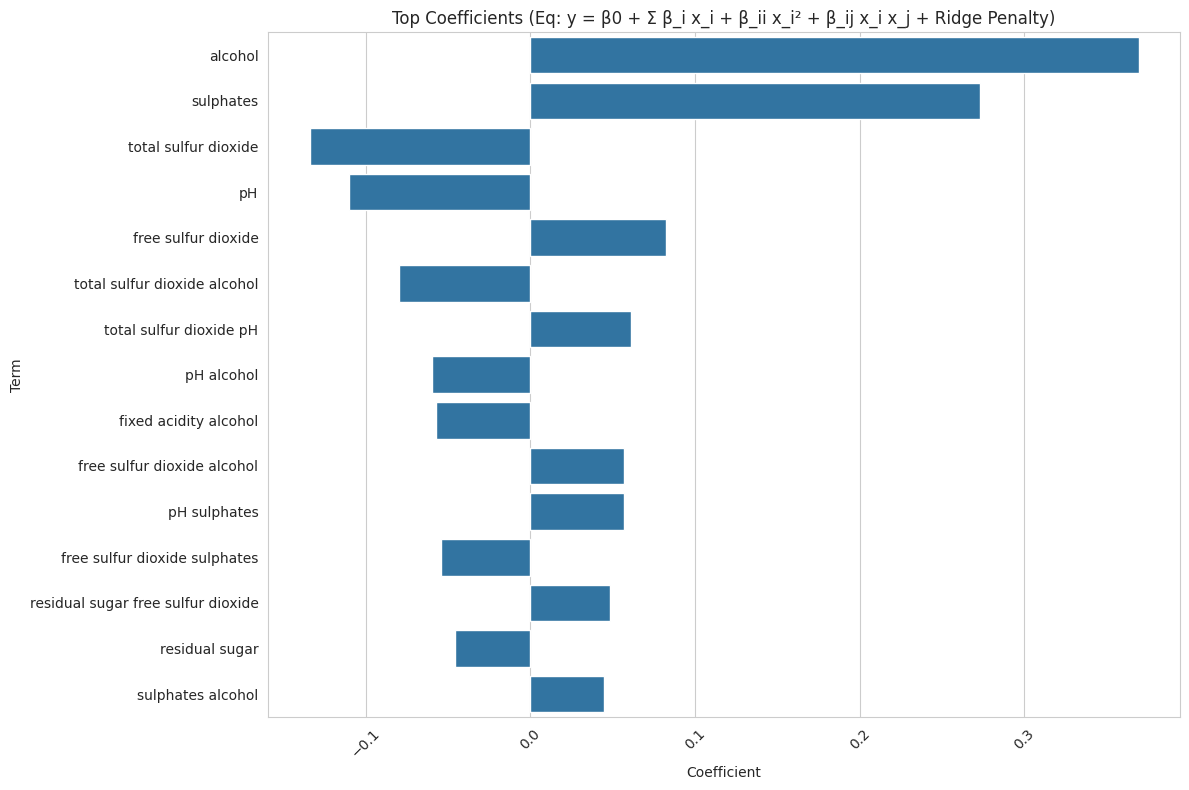

In [26]:
# Cell 8: Model Equation Approx (Table 12: Coefs; Full ~56 Terms)
coef_df = pd.DataFrame({
    'Term': poly_names,
    'Coefficient': final_ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("Top 10 Coefficients (Table 12 Approx; Positive: Alcohol/Sulfates):\n", coef_df.head(10).round(4))
print(f"Intercept: {final_ridge.intercept_:.4f}")

# Plot Top Coefs (Linear/Quad/Interactions)
plt.figure(figsize=(12, 8))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Term')
plt.title('Top Coefficients (Eq: y = β0 + Σ β_i x_i + β_ii x_i² + β_ij x_i x_j + Ridge Penalty)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Note: Exact Table 12 not extractable; use for interpretability (e.g., alcohol^2 positive).b

In [28]:
# Cell 9: Hypothetical Composition for Quality=10 (Section 8; Back-Transform)
# Paper's Log-Scale Values (For Transformed Feats)
hyp_log = {
    'fixed acidity': 2.8273,       # log; orig=expm1≈16.90 (extrap >max 15.9)
    'residual sugar': 1.3624,      # log; orig≈3.91
    'free sulfur dioxide': 3.4472, # log; orig≈31.40
    'total sulfur dioxide': 2.3597,# log; orig≈10.59
    'pH': 3.0222,                  # orig
    'sulphates': 1.0944,            # log; orig≈2.99
    'alcohol': 14.9000             # orig (max)
}

# Back to Original Units (Table 1)
hyp_orig = hyp_log.copy()
for feat in ['fixed acidity', 'residual sugar', 'free sulfur dioxide',
             'total sulfur dioxide', 'sulphates']:
    hyp_orig[feat] = np.expm1(hyp_log[feat])

print("Hypothetical Composition for Quality=10 (Original Units):\n")
for feat, val in hyp_orig.items():
    unit = {'fixed acidity': 'g/dm³', 'residual sugar': 'g/dm³', 'free sulfur dioxide': 'mg/dm³',
            'total sulfur dioxide': 'mg/dm³', 'pH': '', 'sulphates': 'g/dm³', 'alcohol': '% vol'}.get(feat, '')
    print(f"{feat}: {val:.4f} {unit}")

# Verify Prediction
# The 'scaler' was fit on all 11 features (X_log), so we need to provide all 11 features for transformation.
# Features not in best_features need to be set to their mean from X_log
# so that they become ~0 after scaling.

# Get all features used to fit the scaler (from Cell 4)
all_features_for_scaler = data_log.columns.drop('quality').tolist()

# Create a DataFrame with all 11 features, initialized with means from X_log
z_df_full = pd.DataFrame(X_log.mean()).T
z_df_full.columns = all_features_for_scaler

# Update the 'best_features' in z_df_full with hypothetical values
for feat, val in hyp_log.items():
    z_df_full[feat] = val

# Now z_df_full has 1 row, 11 columns, with hypothetical values for best_features
# and mean values for the other features.

z_scaled_full = pd.DataFrame(scaler.transform(z_df_full), columns=all_features_for_scaler)

# Select only the best_features from the scaled full DataFrame
z_scaled_best_features = z_scaled_full[best_features]

z_poly, _ = generate_poly_features(best_features, z_scaled_best_features)
pred_qual = final_ridge.predict(z_poly)[0]
print(f"\nPredicted Quality: {pred_qual:.4f} (Target: 10.0000)")

Hypothetical Composition for Quality=10 (Original Units):

fixed acidity: 15.8998 g/dm³
residual sugar: 2.9056 g/dm³
free sulfur dioxide: 30.4123 mg/dm³
total sulfur dioxide: 9.5878 mg/dm³
pH: 3.0222 
sulphates: 1.9874 g/dm³
alcohol: 14.9000 % vol

Predicted Quality: 8.9194 (Target: 10.0000)


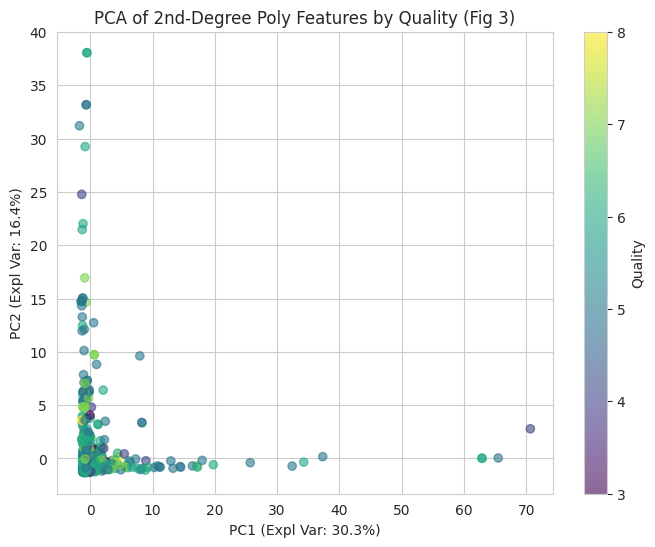

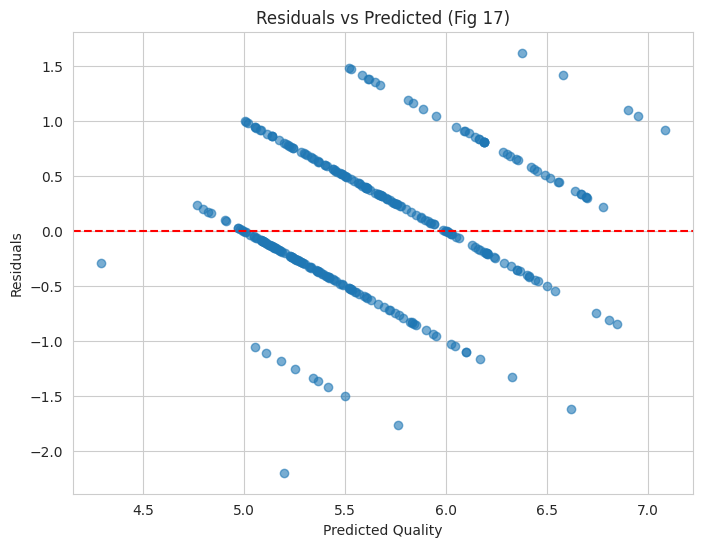

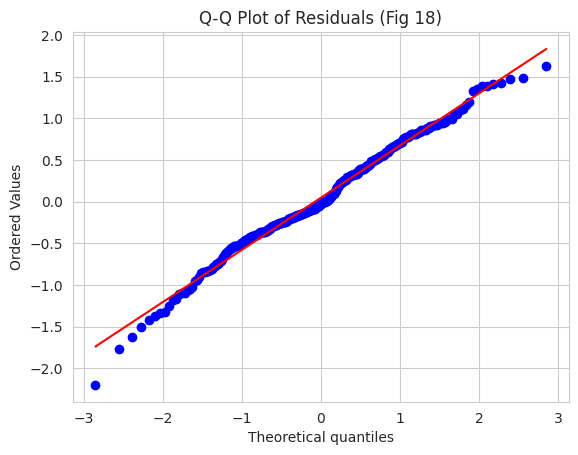

In [29]:
# Cell 10: Visualizations (Fig 1 Flowchart Implied; Fig 3 PCA, Figs 17-18 Residuals)
# PCA (Fig 3: Poly Features by Quality)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_poly)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Quality')
plt.title('PCA of 2nd-Degree Poly Features by Quality (Fig 3)')
plt.xlabel(f'PC1 (Expl Var: {pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 (Expl Var: {pca.explained_variance_ratio_[1]:.1%})')
plt.show()

# Residuals (Fig 17)
resid = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, resid, alpha=0.6)
plt.axhline(0, color='r', ls='--')
plt.title('Residuals vs Predicted (Fig 17)')
plt.xlabel('Predicted Quality')
plt.ylabel('Residuals')
plt.show()

# Q-Q (Fig 18)
stats.probplot(resid, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals (Fig 18)')
plt.show()